First 5 Rows
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

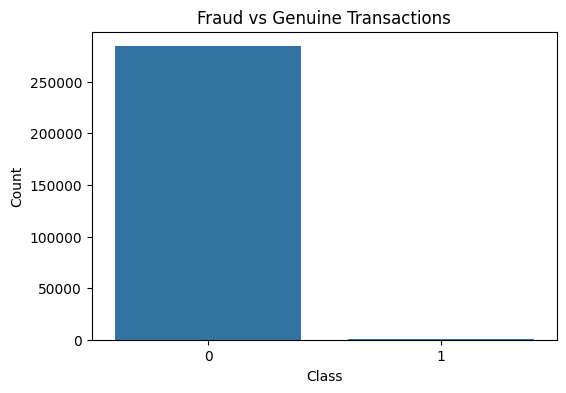

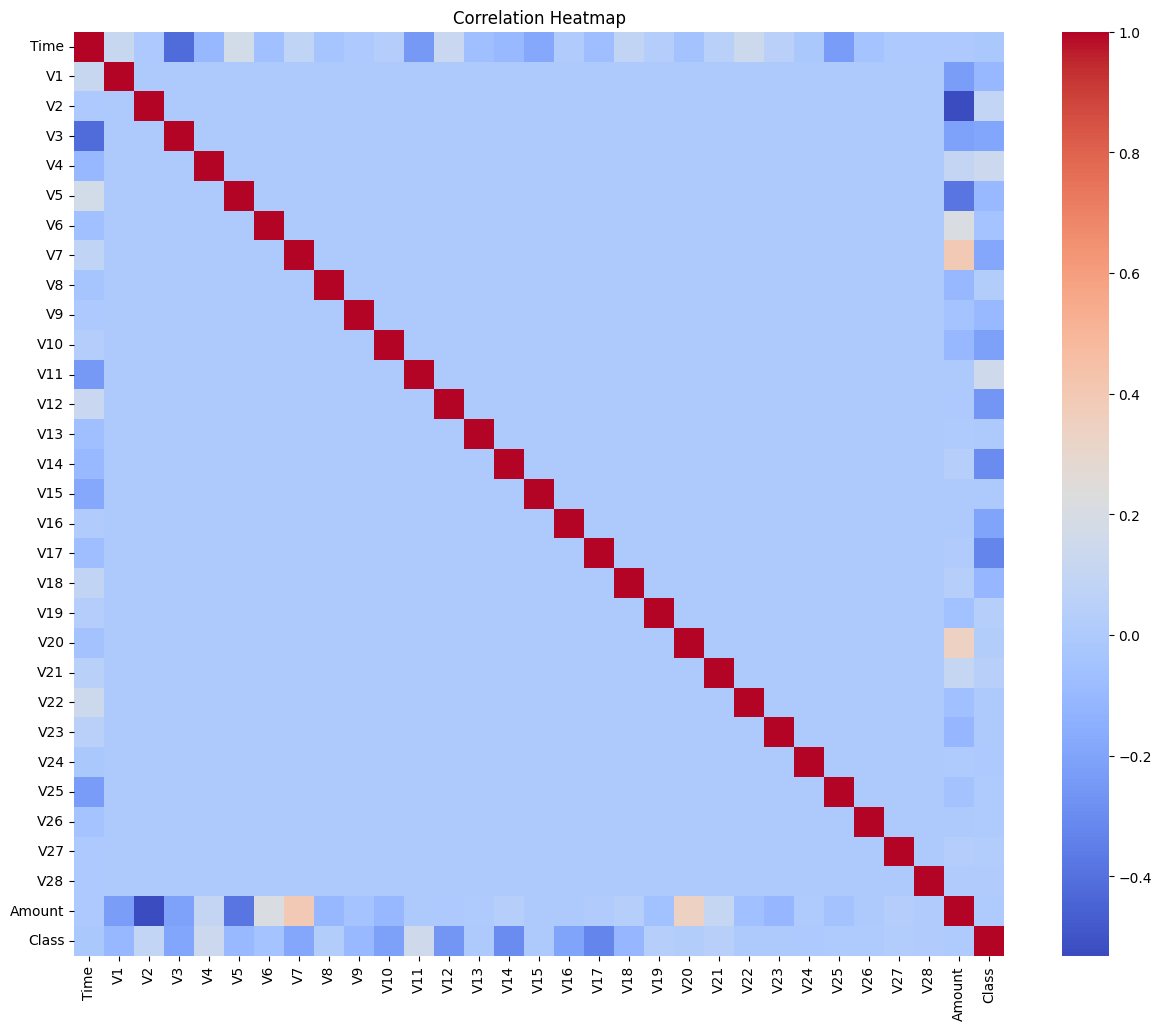


Training Data : (199364, 30)
Testing Data : (85443, 30)

Accuracy : 0.9995201479348805

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443


Confusion Matrix

[[85290     5]
 [   36   112]]


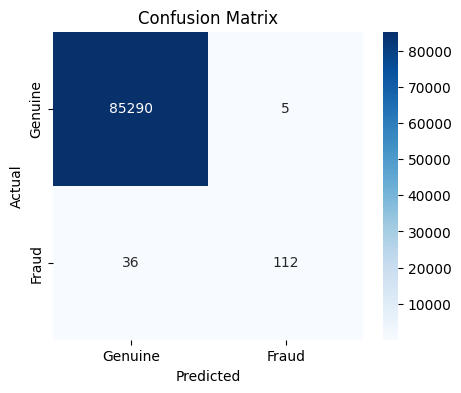


Top 10 Important Features

   Feature  Importance
17     V17    0.165476
12     V12    0.132559
14     V14    0.127484
10     V10    0.079081
16     V16    0.070014
11     V11    0.055651
9       V9    0.036987
18     V18    0.031492
4       V4    0.029619
7       V7    0.028580


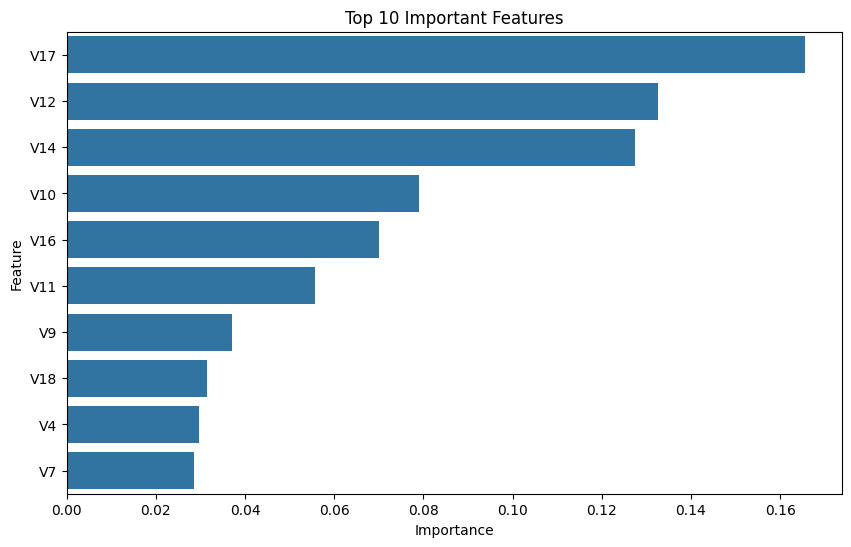


Single Transaction Prediction
Prediction : Genuine Transaction


In [1]:
# ================================
# CREDIT CARD FRAUD DETECTION
# ================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

df = pd.read_csv(url)

# Step 3: Display Dataset
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nClass Distribution")
print(df["Class"].value_counts())

# Step 4: Plot Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Step 5: Correlation Heatmap
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Step 6: Separate Features and Target

X = df.drop("Class", axis=1)
y = df["Class"]

# Step 7: Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining Data :", X_train.shape)
print("Testing Data :", X_test.shape)

# Step 8: Train Random Forest Model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Step 9: Prediction

y_pred = model.predict(X_test)

# Step 10: Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

# Step 11: Classification Report

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Step 12: Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix\n")
print(cm)

# Step 13: Plot Confusion Matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine","Fraud"],
    yticklabels=["Genuine","Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Step 14: Feature Importance

importance = model.feature_importances_

feature_importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features\n")

print(feature_importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

# Step 15: Predict a Single Transaction

print("\nSingle Transaction Prediction")

sample = X.iloc[[100]]

prediction = model.predict(sample)

if prediction[0] == 0:
    print("Prediction : Genuine Transaction")
else:
    print("Prediction : Fraud Transaction")